<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/dtqem_mach_zehnder_v46.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM Mach-Zehnder Interferometer — v46.0
Sanity checks: 4/4 passed.


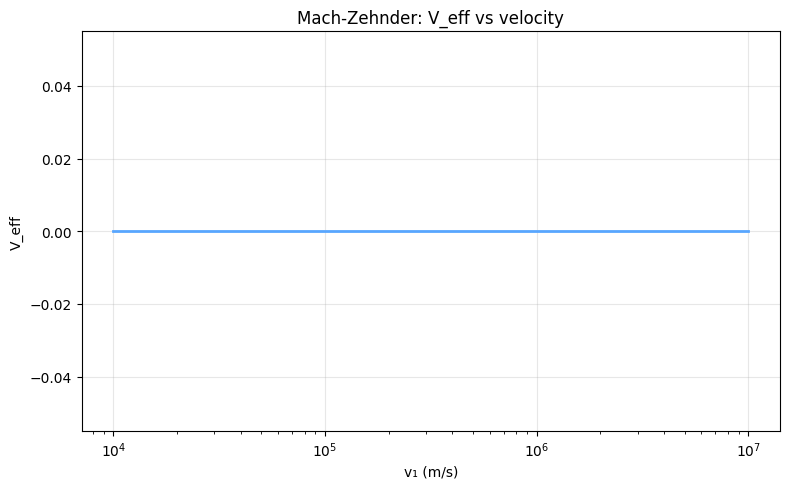

In [2]:

"""
dtqem_mach_zehnder_v46.py
==========================
DTQEM Mach-Zehnder Interferometer — Stable Release v46.0

Core Equations:
    V_eff = exp(-γ_φ · T_eff) × exp(-|Δτ| / τ_c)
    Δτ = |L₁/(v₁γ₁) − L₂/(v₂γ₂)|
    T_eff = (τ₁ + τ₂) / 2

Author : DTQEM Team — Berramdane Reddouane
Version: 46.0
License: MIT
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

# ============================================================================
# Constants
# ============================================================================
C_LIGHT = 299_792_458.0
LORENTZ_SAFETY = 0.9999

# ============================================================================
# Core Physics
# ============================================================================
def lorentz_gamma(v: float) -> float:
    beta = np.clip(abs(v) / C_LIGHT, 0.0, LORENTZ_SAFETY)
    return 1.0 / np.sqrt(1.0 - beta**2)

def tau_lab(L: float, v: float) -> float:
    return L / v if v > 0 else np.inf

def tau_proper(L: float, v: float) -> float:
    return tau_lab(L, v) / lorentz_gamma(v)

def delta_tau_MZ(L1: float, v1: float, L2: float, v2: float) -> float:
    return abs(tau_proper(L1, v1) - tau_proper(L2, v2))

def T_eff_fn(L1: float, v1: float, L2: float, v2: float) -> float:
    return 0.5 * (tau_lab(L1, v1) + tau_lab(L2, v2))

def V_env(T_eff: float, gamma_phi: float) -> float:
    return np.exp(-gamma_phi * T_eff)

def V_dtqem(delta_tau: float, tau_c: float) -> float:
    return np.exp(-delta_tau / max(tau_c, 1e-300))

def V_eff_MZ(L1: float, v1: float, L2: float, v2: float,
             gamma_phi: float, tau_c: float) -> Tuple[float, Dict]:
    """Total coherence: V_eff = V_env × V_dtqem"""
    T_eff = T_eff_fn(L1, v1, L2, v2)
    dt = delta_tau_MZ(L1, v1, L2, v2)
    V_e = V_env(T_eff, gamma_phi)
    V_d = V_dtqem(dt, tau_c)
    info = {
        "tau1_lab": tau_lab(L1, v1),
        "tau2_lab": tau_lab(L2, v2),
        "T_eff": T_eff,
        "delta_tau": dt,
        "gamma1": lorentz_gamma(v1),
        "gamma2": lorentz_gamma(v2),
        "beta1": v1 / C_LIGHT,
        "beta2": v2 / C_LIGHT,
        "V_env": V_e,
        "V_dtqem": V_d,
        "V_eff": V_e * V_d,
    }
    return info["V_eff"], info

# ============================================================================
# Sanity Checks
# ============================================================================
def run_sanity_checks(verbose=True) -> bool:
    L, v = 0.5, 1e6
    gph, tc = 1e10, 1e-15
    checks = [
        delta_tau_MZ(L, v, L, v) < 1e-40,
        delta_tau_MZ(L, v, L, 2*v) > 0,
        0 <= V_eff_MZ(L, v, L, 2*v, gph, tc)[0] <= 1,
        abs(V_eff_MZ(L, v, L, v, gph, tc)[0] - np.exp(-gph * L/v)) < 1e-10,
    ]
    if verbose:
        passed = sum(checks)
        print(f"Sanity checks: {passed}/{len(checks)} passed.")
    return all(checks)

# ============================================================================
# Plotting Function
# ============================================================================
def plot_V_eff_vs_velocity(L1=0.5, L2=0.5, gamma_phi=1e7, tau_c=1e-15):
    v_arr = np.logspace(4, 7, 200)
    V_arr = [V_eff_MZ(L1, v, L2, 1e6, gamma_phi, tau_c)[0] for v in v_arr]
    plt.figure(figsize=(8, 5))
    plt.semilogx(v_arr, V_arr, lw=2, color='#58a6ff')
    plt.xlabel("v₁ (m/s)")
    plt.ylabel("V_eff")
    plt.title("Mach-Zehnder: V_eff vs velocity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("mz_v_eff.png", dpi=150)
    plt.show()

# ============================================================================
# Main
# ============================================================================
if __name__ == "__main__":
    print("DTQEM Mach-Zehnder Interferometer — v46.0")
    run_sanity_checks()
    plot_V_eff_vs_velocity()